In [1]:

from __future__ import annotations

from pathlib import Path
import json
import re
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.two_tower_training import TrainConfig, TwoTowerMLP, chronological_split  # noqa: E402

MODEL_TAG = "bestmodel_v3"
PREFIX = "vehicle_sensor_subset_200ms_expanded_features"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
BEST_DIR = PROJECT_ROOT / "experiments" / "static_action_two_tower" / MODEL_TAG
V2_TABLE_DIR = PROJECT_ROOT / "reports" / "tables" / "bestmodel_v2"
REPORT_DIR = PROJECT_ROOT / "reports" / MODEL_TAG
FIG_DIR = PROJECT_ROOT / "reports" / "figures" / MODEL_TAG
TABLE_DIR = PROJECT_ROOT / "reports" / "tables" / MODEL_TAG
for path in (REPORT_DIR, FIG_DIR, TABLE_DIR):
    path.mkdir(parents=True, exist_ok=True)

checkpoint_path = BEST_DIR / f"{MODEL_TAG}_complete_checkpoint.pt"
embedding_path = BEST_DIR / "static_action_embeddings.npz"
info_path = BEST_DIR / f"{MODEL_TAG}_info.json"
manifest_path = BEST_DIR / "source_feature_manifest.json"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DEVICE:", DEVICE)
print("checkpoint:", checkpoint_path)

try:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
with open(info_path, "r", encoding="utf-8") as f:
    best_info = json.load(f)
with open(manifest_path, "r", encoding="utf-8") as f:
    manifest = json.load(f)

config = TrainConfig(**checkpoint["config"])
context_feature_names = list(manifest["context_feature_names"])
static_action_feature_names = list(manifest["static_action_feature_names"])

model = TwoTowerMLP(
    context_dim=int(checkpoint["context_dim"]),
    action_dim=int(checkpoint["action_dim"]),
    hidden=config.hidden,
    emb_dim=config.emb_dim,
    depth=config.depth,
    dropout=config.dropout,
    combine_mode=config.combine_mode,
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

arrays = np.load(PROCESSED_DIR / f"{PREFIX}_arrays.npz", allow_pickle=True)
with open(PROCESSED_DIR / f"{PREFIX}_meta.json", "r", encoding="utf-8") as f:
    base_meta = json.load(f)
examples_index = pd.read_csv(PROCESSED_DIR / f"{PREFIX}_examples_index.csv")
examples_index["subset_str"] = examples_index["subset_str"].astype(str)
examples_index["datetime"] = pd.to_datetime(examples_index["datetime"])

C_base = arrays["C_by_time"].astype(np.float32)
y_examples = arrays["y_examples"].astype(np.float32)
time_id_all = arrays["example_time_id"].astype(np.int64)
sequence_times = pd.to_datetime(arrays["sequence_times"])
ordered_nodes = [int(n) for n in base_meta["ordered_nodes"]]
node_to_idx = {node: i for i, node in enumerate(ordered_nodes)}
base_context_names = list(base_meta["context_feature_names"])
base_context_index = {name: i for i, name in enumerate(base_context_names)}

refined_long = pd.read_csv(PROCESSED_DIR / "vehicle_sensor_subset_200ms_refined_audio_bands_long.csv")
refined_long["datetime"] = pd.to_datetime(refined_long["datetime"])
refined_long["node"] = refined_long["node"].astype(int)
refined_pivots = {}
for feature in manifest["refined_audio_features_added"]:
    pivot = refined_long.pivot_table(index="datetime", columns="node", values=feature, aggfunc="first")
    pivot = pivot.sort_index().reindex(index=pd.DatetimeIndex(sequence_times), columns=ordered_nodes)
    arr = pivot.ffill().bfill().to_numpy(dtype=np.float32)
    if np.isnan(arr).any():
        fill = np.nanmedian(arr) if np.isfinite(arr).any() else 0.0
        arr = np.nan_to_num(arr, nan=float(fill)).astype(np.float32)
    refined_pivots[feature] = arr

def build_v3_context_matrix() -> np.ndarray:
    cols = []
    for name in context_feature_names:
        if name in base_context_index:
            cols.append(C_base[:, base_context_index[name]].astype(np.float32))
            continue
        match = re.match(r"^n(\d+)_audio_(.+)$", name)
        if match is None:
            raise KeyError(f"Cannot reconstruct v3 context feature: {name}")
        node = int(match.group(1))
        feature = match.group(2)
        cols.append(refined_pivots[feature][:, node_to_idx[node]].astype(np.float32))
    return np.column_stack(cols).astype(np.float32)

C_v3 = build_v3_context_matrix()
if C_v3.shape[1] != int(checkpoint["context_dim"]):
    raise RuntimeError(f"Context dim mismatch: {C_v3.shape[1]} vs {checkpoint['context_dim']}")

standardizers = checkpoint["standardizers"]
C_mu = np.asarray(standardizers["C_mu"], dtype=np.float32)
C_sigma = np.asarray(standardizers["C_sigma"], dtype=np.float32)
C_sigma = np.where(np.abs(C_sigma) < 1e-12, 1.0, C_sigma).astype(np.float32)
C_std = ((C_v3 - C_mu) / C_sigma).astype(np.float32)

emb_npz = np.load(embedding_path, allow_pickle=True)
action_embedding_keys = [str(x) for x in emb_npz["subset_key"]]
action_embeddings_np = emb_npz["action_embeddings"].astype(np.float32)
action_vectors_std_np = emb_npz["action_vectors_std"].astype(np.float32)
subset_to_action_id = {key: i for i, key in enumerate(action_embedding_keys)}
action_id_all = examples_index["subset_str"].map(subset_to_action_id).to_numpy()
if pd.isna(action_id_all).any():
    missing = examples_index.loc[pd.isna(action_id_all), "subset_str"].unique().tolist()
    raise ValueError(f"Subsets missing from static action embedding cache: {missing}")
action_id_all = action_id_all.astype(np.int64)

with torch.no_grad():
    context_embeddings = model.embed_context(torch.from_numpy(C_std).to(DEVICE)).detach().cpu().numpy().astype(np.float32)

scores = np.empty(len(examples_index), dtype=np.float32)
batch_size = max(32768, config.batch_size * 4)
C_emb_tensor = torch.from_numpy(context_embeddings).to(DEVICE)
A_emb_tensor = torch.from_numpy(action_embeddings_np).to(DEVICE)
with torch.no_grad():
    for start in range(0, len(scores), batch_size):
        end = min(start + batch_size, len(scores))
        c_batch = C_emb_tensor[torch.from_numpy(time_id_all[start:end]).to(DEVICE)]
        a_batch = A_emb_tensor[torch.from_numpy(action_id_all[start:end]).to(DEVICE)]
        scores[start:end] = model.score_embeddings(c_batch, a_batch).detach().cpu().numpy().astype(np.float32)

split = chronological_split(time_id_all, n_times=len(C_v3), train_frac=config.train_frac, val_frac=config.val_frac)
split_by_time = {}
for split_name in ("train", "val", "test"):
    for tid in split[f"{split_name}_time_ids"]:
        split_by_time[int(tid)] = split_name

score_df = examples_index.copy()
score_df["score"] = scores
score_df["saved_utility"] = y_examples
score_df["action_id"] = action_id_all
score_df["split"] = score_df["time_id"].map(split_by_time)

rows = []
eps = 1e-10
for tid, g in score_df.groupby("time_id", sort=False):
    y = g["saved_utility"].to_numpy(dtype=float)
    sc = g["score"].to_numpy(dtype=float)
    pred_pos = int(np.argmax(sc))
    selected = g.iloc[pred_pos]
    selected_value = float(y[pred_pos])
    sorted_y = np.sort(y)[::-1]
    best_value = float(sorted_y[0])
    second_value = float(sorted_y[1]) if len(sorted_y) > 1 else best_value
    worst_value = float(sorted_y[-1])
    rank = int(np.sum(y > selected_value + eps)) + 1
    regret = best_value - selected_value
    norm_regret = regret / max(best_value - worst_value, eps)
    rows.append({
        "time_id": int(tid),
        "datetime": selected["datetime"],
        "split": split_by_time[int(tid)],
        "selected_subset": str(selected["subset_str"]),
        "selected_subset_size": int(selected["subset_size"]),
        "closest_node": int(selected["closest_node"]),
        "signal_top1_node": int(selected["signal_top1_node"]) if "signal_top1_node" in selected.index else np.nan,
        "contains_closest": float(selected["contains_closest_node"] > 0.5),
        "saved_top1": float(rank == 1),
        "saved_top3": float(rank <= 3),
        "saved_rank": float(rank),
        "selected_value": selected_value,
        "best_value": best_value,
        "second_best_value": second_value,
        "worst_value": worst_value,
        "regret": regret,
        "norm_regret": norm_regret,
        "true_top1_top2_gap": best_value - second_value,
        "selected_score": float(sc[pred_pos]),
    })

per_time_df = pd.DataFrame(rows).sort_values("time_id").reset_index(drop=True)
per_time_df["datetime"] = pd.to_datetime(per_time_df["datetime"])
per_time_df["elapsed_s"] = (per_time_df["datetime"] - per_time_df["datetime"].min()).dt.total_seconds()
per_time_df["elapsed_min"] = per_time_df["elapsed_s"] / 60.0

split_summary_df = (
    per_time_df.groupby("split", sort=False)
    .agg(
        n_times=("time_id", "count"),
        contains_closest=("contains_closest", "mean"),
        saved_top1=("saved_top1", "mean"),
        saved_top3=("saved_top3", "mean"),
        mean_rank=("saved_rank", "mean"),
        avg_regret=("regret", "mean"),
        avg_norm_regret=("norm_regret", "mean"),
    )
    .reset_index()
)

vehicle_gt_path = PROCESSED_DIR / f"{PREFIX}_ground_truth_vehicle.csv"
if vehicle_gt_path.exists():
    vehicle_gt = pd.read_csv(vehicle_gt_path)
    vehicle_gt["datetime"] = pd.to_datetime(vehicle_gt["datetime"])
    spatial_df = per_time_df.merge(vehicle_gt, on="datetime", how="left", suffixes=("", "_gt"))
else:
    spatial_df = per_time_df.copy()

per_time_path = TABLE_DIR / f"{MODEL_TAG}_per_time_decisions.csv"
spatial_path = TABLE_DIR / f"{MODEL_TAG}_spatial_decisions.csv"
split_summary_path = TABLE_DIR / f"{MODEL_TAG}_split_summary.csv"
score_sample_path = TABLE_DIR / f"{MODEL_TAG}_example_scores_sample.csv"
per_time_df.to_csv(per_time_path, index=False)
spatial_df.to_csv(spatial_path, index=False)
split_summary_df.to_csv(split_summary_path, index=False)
score_df.sample(min(50000, len(score_df)), random_state=22).to_csv(score_sample_path, index=False)

print("Scored examples:", score_df.shape)
print("Per-time decisions:", per_time_df.shape)
print("Context/action dims:", C_v3.shape[1], action_vectors_std_np.shape[1])
print("Static action embedding table:", action_embeddings_np.shape)
print("Saved tables:", TABLE_DIR)
display(split_summary_df)
display(pd.read_csv(BEST_DIR / "common_eval.csv"))


PROJECT_ROOT: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt
DEVICE: cuda
checkpoint: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\experiments\static_action_two_tower\bestmodel_v3\bestmodel_v3_complete_checkpoint.pt
Scored examples: (306065, 17)
Per-time decisions: (7465, 21)
Context/action dims: 54 13
Static action embedding table: (41, 16)
Saved tables: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v3


,split,n_times,contains_closest,saved_top1,saved_top3,mean_rank,avg_regret,avg_norm_regret
0,train,4479,1.000000,0.755079,0.981023,1.333557,0.001667,0.003401
1,val,1493,0.985934,0.545881,0.825854,2.398526,0.008440,0.018572
2,test,1493,0.983925,0.535834,0.806430,2.526457,0.010035,0.020708


,run_name,train_utility,eval_objective,split,hidden,emb_dim,combine,top1,top3,mean_rank,avg_regret,avg_norm_regret
0,v3_drop_rssi_drop_spectral_db_only_h512_d2_e16,saved,contains_closest,test,512,16,mul_only,0.983925,0.983925,1.257200,0.016075,0.016075
1,v3_drop_rssi_drop_spectral_db_only_h512_d2_e16,saved,contains_closest,train,512,16,mul_only,1.000000,1.000000,1.000000,0.000000,0.000000
2,v3_drop_rssi_drop_spectral_db_only_h512_d2_e16,saved,contains_closest,val,512,16,mul_only,0.985934,0.985934,1.225050,0.014066,0.014066
3,v3_drop_rssi_drop_spectral_db_only_h512_d2_e16,saved,rank_discount,test,512,16,mul_only,0.983925,0.983925,1.325519,0.009042,0.010851
4,v3_drop_rssi_drop_spectral_db_only_h512_d2_e16,saved,rank_discount,train,512,16,mul_only,1.000000,1.000000,1.000000,0.000000,0.000000
5,v3_drop_rssi_drop_spectral_db_only_h512_d2_e16,saved,rank_discount,val,512,16,mul_only,0.985934,0.985934,1.232418,0.007144,0.008573
6,v3_drop_rssi_drop_spectral_db_only_h512_d2_e16,saved,saved_rational,test,512,16,mul_only,0.535834,0.806430,2.526457,0.010035,0.020708
7,v3_drop_rssi_drop_spectral_db_only_h512_d2_e16,saved,saved_rational,train,512,16,mul_only,0.755079,0.981023,1.333557,0.001667,0.003401
8,v3_drop_rssi_drop_spectral_db_only_h512_d2_e16,saved,saved_rational,val,512,16,mul_only,0.545881,0.825854,2.398526,0.008440,0.018572


Using saved CSVs:
  Two-Tower  : d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v3\bestmodel_v3_per_time_decisions.csv
  Linear fit : d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v2\iobt_pathloss_baseline_per_time_test.csv
  Spline fit : d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v2\iobt_spline_cvxpy_baseline_per_time_test.csv
  KDE        : d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v2\kde_hybrid_baseline_per_time_test.csv
  Normalized : d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v2\normalized_top_p_baseline_per_time_test.csv


,method,n_valid,mean_accuracy,std_error_binomial,n_common_times,mean_accuracy_common_times
0,Two-Tower,1493,0.983925,0.003255,1493,0.983925
1,Linear fit,1493,0.770261,0.010887,1493,0.770261
2,Spline fit,1493,0.713329,0.011703,1493,0.713329
3,KDE,1493,0.727395,0.011525,1493,0.727395
4,Normalized,1493,0.759545,0.011060,1493,0.759545


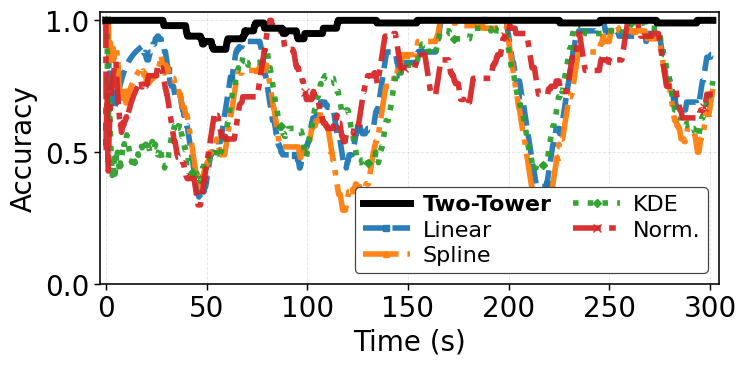

Saved:
  d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\figures\bestmodel_v3\all_methods_time_vs_accuracy_double_column_styled.pdf
  d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\figures\bestmodel_v3\all_methods_time_vs_accuracy_double_column_styled.png
  d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v3\all_methods_mean_accuracy_table.csv
  d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v3\all_methods_merged_per_time_accuracy.csv
  d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v3\all_methods_mean_accuracy_table_latex.txt


In [2]:

# %% Paper-level all-method time-vs-accuracy plot and mean-accuracy table for bestmodel_v3
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROLLING_WINDOW = 100
OUT_STEM = "all_methods_time_vs_accuracy_double_column_styled"
FIGSIZE = (7.35, 3.55)

TABLE_DIR = Path(TABLE_DIR)
FIG_DIR = Path(FIG_DIR)
V2_TABLE_DIR = Path(V2_TABLE_DIR)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 16,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 1.15,
    "xtick.major.width": 1.05,
    "ytick.major.width": 1.05,
    "xtick.major.size": 4.0,
    "ytick.major.size": 4.0,
})

STYLE = {
    "Two-Tower": {"label": "Two-Tower", "color": "black", "linestyle": "-", "linewidth": 5.0, "marker": None, "markersize": 0, "markevery": None, "zorder": 30, "alpha": 1.0},
    "Linear fit": {"label": "Linear", "color": "tab:blue", "linestyle": "--", "linewidth": 4.0, "marker": "s", "markersize": 4.4, "markevery": 155, "zorder": 10, "alpha": 0.95},
    "Spline fit": {"label": "Spline", "color": "tab:orange", "linestyle": "-.", "linewidth": 4.0, "marker": "^", "markersize": 4.8, "markevery": 185, "zorder": 10, "alpha": 0.95},
    "KDE": {"label": "KDE", "color": "tab:green", "linestyle": ":", "linewidth": 4.0, "marker": "D", "markersize": 4.2, "markevery": 215, "zorder": 10, "alpha": 0.95},
    "Normalized": {"label": "Norm.", "color": "tab:red", "linestyle": (0, (5.0, 1.5, 1.2, 1.5)), "linewidth": 4.0, "marker": "x", "markersize": 5.2, "markevery": 245, "zorder": 10, "alpha": 0.95},
}

def load_method_csv(label: str, path: Path, metric_candidates: list[str]) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"{label}: missing CSV {path}")
    df = pd.read_csv(path)
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    if "split" in df.columns:
        df = df[df["split"].astype(str).str.lower().eq("test")].copy()
    metric_col = next((c for c in metric_candidates if c in df.columns), None)
    if metric_col is None:
        raise ValueError(f"{label}: none of {metric_candidates} found in {path.name}; columns={list(df.columns)}")
    if "time_id" not in df.columns:
        df["time_id"] = np.arange(len(df), dtype=int)
    keep_cols = ["time_id", metric_col]
    if "datetime" in df.columns:
        keep_cols.insert(1, "datetime")
    out = df[keep_cols].copy()
    out["time_id"] = out["time_id"].astype(int)
    out = out.rename(columns={metric_col: label})
    out[label] = pd.to_numeric(out[label], errors="coerce")
    agg = {label: "mean"}
    if "datetime" in out.columns:
        agg["datetime"] = "first"
    return out.groupby("time_id", as_index=False).agg(agg)

paths = {
    "Two-Tower": TABLE_DIR / f"{MODEL_TAG}_per_time_decisions.csv",
    "Linear fit": V2_TABLE_DIR / "iobt_pathloss_baseline_per_time_test.csv",
    "Spline fit": V2_TABLE_DIR / "iobt_spline_cvxpy_baseline_per_time_test.csv",
    "KDE": V2_TABLE_DIR / "kde_hybrid_baseline_per_time_test.csv",
    "Normalized": V2_TABLE_DIR / "normalized_top_p_baseline_per_time_test.csv",
}

print("Using saved CSVs:")
for key, value in paths.items():
    print(f"  {key:11s}: {value}")

method_dfs = [
    load_method_csv("Two-Tower", paths["Two-Tower"], ["contains_closest", "two_tower_contains_closest", "model_contains_closest"]),
    load_method_csv("Linear fit", paths["Linear fit"], ["pathloss_contains_closest", "path_loss_correct", "linear_contains_closest"]),
    load_method_csv("Spline fit", paths["Spline fit"], ["spline_contains_closest", "spline_correct"]),
    load_method_csv("KDE", paths["KDE"], ["kde_hybrid_contains_closest", "kde_contains_closest"]),
    load_method_csv("Normalized", paths["Normalized"], ["normalized_top_p_success", "normalized_contains_closest"]),
]

merged = None
for df in method_dfs:
    if merged is None:
        merged = df.copy()
    else:
        if "datetime" in merged.columns and "datetime" in df.columns:
            df = df.drop(columns=["datetime"])
        merged = merged.merge(df, on="time_id", how="outer")
merged = merged.sort_values("time_id").reset_index(drop=True)

methods = ["Two-Tower", "Linear fit", "Spline fit", "KDE", "Normalized"]
if "datetime" in merged.columns and merged["datetime"].notna().any():
    merged["datetime"] = pd.to_datetime(merged["datetime"], errors="coerce")
    t0 = merged["datetime"].dropna().iloc[0]
    x = (merged["datetime"] - t0).dt.total_seconds()
    x_label = "Time (s)"
else:
    x = merged["time_id"]
    x_label = "Test index"

common_mask = merged[methods].notna().all(axis=1)
summary_rows = []
for method in methods:
    vals = merged[method].dropna()
    common_vals = merged.loc[common_mask, method].dropna()
    mean_acc = float(vals.mean())
    n = int(vals.shape[0])
    se = float(np.sqrt(mean_acc * (1.0 - mean_acc) / n)) if n > 0 else np.nan
    summary_rows.append({
        "method": method,
        "display_name": STYLE[method]["label"],
        "n_valid": n,
        "mean_accuracy": mean_acc,
        "std_error_binomial": se,
        "n_common_times": int(common_vals.shape[0]),
        "mean_accuracy_common_times": float(common_vals.mean()) if len(common_vals) else np.nan,
        "rolling_window": ROLLING_WINDOW,
        "source_csv": str(paths[method]),
    })
summary_df = pd.DataFrame(summary_rows)

summary_csv = TABLE_DIR / "all_methods_mean_accuracy_table.csv"
merged_csv = TABLE_DIR / "all_methods_merged_per_time_accuracy.csv"
latex_txt = TABLE_DIR / "all_methods_mean_accuracy_table_latex.txt"
summary_df.to_csv(summary_csv, index=False)
merged.to_csv(merged_csv, index=False)
latex_txt.write_text(
    "\n".join(
        f"{row.display_name} & {100.0 * row.mean_accuracy:.2f} & {100.0 * row.mean_accuracy_common_times:.2f} & {row.n_valid} \\\\"
        for row in summary_df.itertuples(index=False)
    ),
    encoding="utf-8",
)

display(summary_df[["method", "n_valid", "mean_accuracy", "std_error_binomial", "n_common_times", "mean_accuracy_common_times"]])

fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
for method in methods:
    y = merged[method].rolling(ROLLING_WINDOW, min_periods=1).mean()
    st = STYLE[method]
    plot_kwargs = dict(label=st["label"], color=st["color"], linestyle=st["linestyle"], linewidth=st["linewidth"], zorder=st["zorder"], alpha=st["alpha"])
    if st["marker"] is not None:
        plot_kwargs.update(marker=st["marker"], markersize=st["markersize"], markevery=st["markevery"])
    ax.plot(x, y, **plot_kwargs)

ax.set_ylim(0.0, 1.03)
ax.set_xlabel(x_label, labelpad=4)
ax.set_ylabel("Accuracy", labelpad=5)
ax.grid(True, linestyle="--", linewidth=0.65, alpha=0.32)
ax.set_axisbelow(True)
ax.margins(x=0.01)
leg = ax.legend(loc="lower right", ncol=2, frameon=True, framealpha=1.0, facecolor="white", edgecolor="0.25", borderpad=0.34, handlelength=2.15, handletextpad=0.55, columnspacing=0.95, labelspacing=0.24)
leg.set_zorder(10000)
leg.get_frame().set_zorder(10001)
leg.get_frame().set_linewidth(0.85)
for text in leg.get_texts():
    text.set_zorder(10003)
    if text.get_text() == STYLE["Two-Tower"]["label"]:
        text.set_fontweight("bold")
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontweight("medium")

pdf_path = FIG_DIR / f"{OUT_STEM}.pdf"
png_path = FIG_DIR / f"{OUT_STEM}.png"
fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=700, bbox_inches="tight")
plt.show()

print("Saved:")
print(" ", pdf_path)
print(" ", png_path)
print(" ", summary_csv)
print(" ", merged_csv)
print(" ", latex_txt)


In [3]:

# %% Compute-side end-to-end online runtime for bestmodel_v3 and unchanged baselines
from pathlib import Path
import gc
import importlib.util
import os
import platform
import re
import sys
import time

import numpy as np
import pandas as pd
import torch
from IPython.display import display

try:
    import soundfile as sf
except Exception as exc:
    sf = None
    print("soundfile unavailable; v3 PCM feature timing will fail until installed:", repr(exc))

TABLE_DIR = Path(TABLE_DIR)
V2_TABLE_DIR = Path(V2_TABLE_DIR)
RAW_DIR = Path(RAW_DIR)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

E2E_REPEATS = 20
E2E_WARMUP_STEPS = 200
SAMPLE_RATE = 16000
SAMPLE_MS = 200
FRAME_LEN = int(round(SAMPLE_RATE * SAMPLE_MS / 1000.0))
EPS = np.finfo(np.float32).eps
REFINED_BANDS = [(20, 80), (80, 160), (160, 400), (400, 900), (900, 2000), (2000, 3500), (3500, 6000)]
BAND_NAMES = [f"band_{lo}_{hi}_db" for lo, hi in REFINED_BANDS]
BAND_TO_IDX = {name: i for i, name in enumerate(BAND_NAMES)}

baseline_runtime_path = V2_TABLE_DIR / "all_methods_accuracy_and_compute_side_runtime.csv"
accuracy_path = TABLE_DIR / "all_methods_mean_accuracy_table.csv"
if not baseline_runtime_path.exists():
    raise FileNotFoundError(baseline_runtime_path)
if not accuracy_path.exists():
    raise FileNotFoundError(f"Missing {accuracy_path}; run the all-method accuracy cell first.")

baseline_runtime_df = pd.read_csv(baseline_runtime_path)
accuracy_df = pd.read_csv(accuracy_path)
accuracy_lookup = accuracy_df.set_index("method")["mean_accuracy"].to_dict()

try:
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

runtime_config = TrainConfig(**checkpoint["config"])
runtime_model = TwoTowerMLP(
    context_dim=int(checkpoint["context_dim"]),
    action_dim=int(checkpoint["action_dim"]),
    hidden=runtime_config.hidden,
    emb_dim=runtime_config.emb_dim,
    depth=runtime_config.depth,
    dropout=runtime_config.dropout,
    combine_mode=runtime_config.combine_mode,
).cpu()
runtime_model.load_state_dict(checkpoint["model_state_dict"])
runtime_model.eval()
A_emb_cpu = torch.from_numpy(action_embeddings_np.astype(np.float32)).cpu()

test_time_ids = per_time_df.loc[per_time_df["split"].eq("test"), "time_id"].astype(int).to_numpy()
min_tid = int(test_time_ids.min())
max_tid = int(test_time_ids.max())
start_sample = min_tid * FRAME_LEN
stop_sample = (max_tid + 1) * FRAME_LEN

if sf is None:
    raise RuntimeError("soundfile is required for PCM feature runtime benchmarking.")

node_audio = {}
for node in ordered_nodes:
    matches = sorted(RAW_DIR.glob(f"*_{node}_respeaker.flac"))
    if not matches:
        raise FileNotFoundError(f"Missing FLAC for node {node} in {RAW_DIR}")
    audio, sr = sf.read(matches[0], start=start_sample, stop=stop_sample, dtype="float32", always_2d=True)
    if int(sr) != SAMPLE_RATE:
        raise ValueError(f"Unexpected sample rate for node {node}: {sr}")
    if audio.shape[1] == 1:
        mono = audio[:, 0]
    else:
        hi = min(audio.shape[1], 5)
        mono = audio[:, 1:hi].mean(axis=1)
    expected = (max_tid - min_tid + 1) * FRAME_LEN
    if mono.shape[0] < expected:
        raise RuntimeError(f"Node {node} audio segment too short: {mono.shape[0]} < {expected}")
    node_audio[node] = mono.astype(np.float32, copy=False)

freqs = np.fft.rfftfreq(FRAME_LEN, d=1.0 / SAMPLE_RATE).astype(np.float32)
band_masks = [(freqs >= lo) & (freqs < hi) for lo, hi in REFINED_BANDS]
window = np.hanning(FRAME_LEN).astype(np.float32)

sensor_x = np.array([C_v3[0, context_feature_names.index(f"n{node}_sensor_x_norm")] for node in ordered_nodes], dtype=np.float32)
sensor_y = np.array([C_v3[0, context_feature_names.index(f"n{node}_sensor_y_norm")] for node in ordered_nodes], dtype=np.float32)

def frames_for_time_id(time_id: int) -> np.ndarray:
    rel = (int(time_id) - min_tid) * FRAME_LEN
    return np.stack([node_audio[node][rel : rel + FRAME_LEN] for node in ordered_nodes]).astype(np.float32, copy=False)

def extract_v3_band_db(frames_by_node: np.ndarray) -> np.ndarray:
    centered = frames_by_node - frames_by_node.mean(axis=1, keepdims=True)
    spectrum = np.fft.rfft(centered * window[None, :], axis=1)
    power = np.abs(spectrum).astype(np.float32) ** 2
    band_db = np.empty((len(ordered_nodes), len(REFINED_BANDS)), dtype=np.float32)
    for j, mask in enumerate(band_masks):
        band_power = power[:, mask].sum(axis=1)
        band_db[:, j] = 10.0 * np.log10(band_power + EPS)
    return band_db

def assemble_v3_context_std(band_db: np.ndarray) -> np.ndarray:
    values = []
    for name in context_feature_names:
        match_geom = re.match(r"^n(\d+)_sensor_([xy])_norm$", name)
        if match_geom is not None:
            node = int(match_geom.group(1))
            idx = node_to_idx[node]
            values.append(sensor_x[idx] if match_geom.group(2) == "x" else sensor_y[idx])
            continue
        match_audio = re.match(r"^n(\d+)_audio_(band_\d+_\d+_db)$", name)
        if match_audio is not None:
            node = int(match_audio.group(1))
            values.append(band_db[node_to_idx[node], BAND_TO_IDX[match_audio.group(2)]])
            continue
        raise KeyError(f"Unexpected v3 context feature {name}")
    raw = np.asarray(values, dtype=np.float32)
    return ((raw - C_mu) / C_sigma).astype(np.float32)

@torch.no_grad()
def decide_v3_subset(context_std: np.ndarray) -> int:
    c = torch.from_numpy(context_std[None, :].astype(np.float32)).cpu()
    c_emb = runtime_model.embed_context(c).expand(A_emb_cpu.shape[0], -1)
    scores = runtime_model.score_embeddings(c_emb, A_emb_cpu)
    return int(torch.argmax(scores).item())

check_tid = int(test_time_ids[0])
check_band_db = extract_v3_band_db(frames_for_time_id(check_tid))
check_context_std = assemble_v3_context_std(check_band_db)
max_abs_context_drift = float(np.max(np.abs(check_context_std - C_std[check_tid])))
print("v3 online context diagnostic max abs drift vs cached row; timing only:", max_abs_context_drift)
print("Context/action dims:", len(context_feature_names), len(static_action_feature_names))

def summarize(vals: np.ndarray) -> dict:
    return {
        "mean_ms": float(vals.mean()),
        "median_ms": float(np.median(vals)),
        "p95_ms": float(np.percentile(vals, 95)),
        "p99_ms": float(np.percentile(vals, 99)),
        "std_ms": float(vals.std()),
        "min_ms": float(vals.min()),
        "max_ms": float(vals.max()),
        "n_timed_calls": int(vals.size),
        "n_test_steps": int(len(test_time_ids)),
        "n_repeats": int(E2E_REPEATS),
    }

def benchmark_component(name: str, fn, *, warmup_steps: int = E2E_WARMUP_STEPS):
    for tid in test_time_ids[: min(int(warmup_steps), len(test_time_ids))]:
        fn(int(tid))
    gc.collect()
    old_gc = gc.isenabled()
    gc.disable()
    raw = []
    try:
        for repeat in range(E2E_REPEATS):
            for step_idx, tid in enumerate(test_time_ids):
                t0 = time.perf_counter_ns()
                fn(int(tid))
                t1 = time.perf_counter_ns()
                raw.append((name, repeat, step_idx, int(tid), (t1 - t0) / 1e6))
    finally:
        if old_gc:
            gc.enable()
    raw_df = pd.DataFrame(raw, columns=["component", "repeat", "step_idx", "time_id", "runtime_ms"])
    summary = {"component": name, **summarize(raw_df["runtime_ms"].to_numpy(dtype=float))}
    return summary, raw_df

band_cache = {int(tid): extract_v3_band_db(frames_for_time_id(int(tid))) for tid in test_time_ids}
context_cache = {int(tid): assemble_v3_context_std(band_cache[int(tid)]) for tid in test_time_ids}

feature_summary, feature_raw = benchmark_component(
    "Two-Tower v3 seven-band PCM feature extraction",
    lambda tid: extract_v3_band_db(frames_for_time_id(tid)),
)
context_summary, context_raw = benchmark_component(
    "Two-Tower v3 context/state assembly",
    lambda tid: assemble_v3_context_std(band_cache[tid]),
)
decision_summary, decision_raw = benchmark_component(
    "Two-Tower v3 decision over 41 static-action embeddings",
    lambda tid: decide_v3_subset(context_cache[tid]),
)

component_summary_df = pd.DataFrame([feature_summary, context_summary, decision_summary])
component_raw_df = pd.concat([feature_raw, context_raw, decision_raw], ignore_index=True)
component_summary_df["context_dim"] = len(context_feature_names)
component_summary_df["action_dim"] = len(static_action_feature_names)
component_summary_df["n_actions"] = len(action_embedding_keys)
component_summary_df["max_abs_context_drift_check"] = max_abs_context_drift
component_summary_df.to_csv(TABLE_DIR / "twotower_v3_online_component_runtime_summary.csv", index=False)
component_raw_df.to_csv(TABLE_DIR / "twotower_v3_online_component_runtime_raw.csv", index=False)

rows = []
for row in baseline_runtime_df.itertuples(index=False):
    method = str(row.method)
    if method == "Two-Tower":
        continue
    accuracy_key = "KDE" if method == "KDE-Hybrid" else method
    rows.append({
        "method": method,
        "mean_accuracy": float(accuracy_lookup.get(accuracy_key, getattr(row, "mean_accuracy", np.nan))),
        "feature_profile": row.feature_profile,
        "feature_mean_ms": float(row.feature_mean_ms),
        "context_state_mean_ms": float(row.context_state_mean_ms),
        "decision_mean_ms": float(row.decision_mean_ms),
        "total_compute_mean_ms": float(row.total_compute_mean_ms),
        "total_compute_median_sum_ms": float(row.total_compute_median_sum_ms),
        "total_compute_p95_component_sum_ms": float(row.total_compute_p95_component_sum_ms),
        "total_compute_steps_per_second_mean": float(row.total_compute_steps_per_second_mean),
        "included_compute": row.included_compute,
        "excluded": row.excluded,
    })

feature_mean = float(feature_summary["mean_ms"])
context_mean = float(context_summary["mean_ms"])
decision_mean = float(decision_summary["mean_ms"])
total_mean = feature_mean + context_mean + decision_mean
total_median = float(feature_summary["median_ms"] + context_summary["median_ms"] + decision_summary["median_ms"])
total_p95 = float(feature_summary["p95_ms"] + context_summary["p95_ms"] + decision_summary["p95_ms"])
rows.append({
    "method": "Two-Tower",
    "mean_accuracy": float(accuracy_lookup.get("Two-Tower", np.nan)),
    "feature_profile": "v3 seven-band FFT dB extraction (6 sensors)",
    "feature_mean_ms": feature_mean,
    "context_state_mean_ms": context_mean,
    "decision_mean_ms": decision_mean,
    "total_compute_mean_ms": total_mean,
    "total_compute_median_sum_ms": total_median,
    "total_compute_p95_component_sum_ms": total_p95,
    "total_compute_steps_per_second_mean": float(1000.0 / max(total_mean, 1e-12)),
    "included_compute": "PCM feature extraction + streaming state/context assembly + decision",
    "excluded": "sensor acquisition, network/MQTT, synchronization wait, packet loss handling, FLAC decode/file I/O, offline fitting/training",
})

method_order = ["Normalized", "Linear fit", "Spline fit", "KDE-Hybrid", "Two-Tower"]
runtime_df = pd.DataFrame(rows)
runtime_df["method_order"] = runtime_df["method"].map({m: i for i, m in enumerate(method_order)})
runtime_df = runtime_df.sort_values("method_order").drop(columns="method_order").reset_index(drop=True)
runtime_df.to_csv(TABLE_DIR / "all_methods_accuracy_and_compute_side_runtime.csv", index=False)
runtime_df.to_csv(TABLE_DIR / "all_methods_compute_side_end_to_end_runtime_summary.csv", index=False)

paper_df = runtime_df[[
    "method",
    "mean_accuracy",
    "feature_mean_ms",
    "context_state_mean_ms",
    "decision_mean_ms",
    "total_compute_mean_ms",
    "total_compute_p95_component_sum_ms",
]].copy()
paper_df.to_csv(TABLE_DIR / "all_methods_total_online_runtime_with_features.csv", index=False)

latex_lines = []
for row in paper_df.itertuples(index=False):
    if row.method == "Two-Tower":
        latex_lines.append(
            f"\\textbf{{Two-Tower}} & {100.0 * row.mean_accuracy:.2f} & \\textbf{{{row.feature_mean_ms:.4f}}} & \\textbf{{{row.total_compute_mean_ms:.4f}}} & \\textbf{{{row.total_compute_p95_component_sum_ms:.4f}}} \\\\"
        )
    else:
        latex_lines.append(
            f"{row.method} & {100.0 * row.mean_accuracy:.2f} & {row.feature_mean_ms:.4f} & {row.total_compute_mean_ms:.4f} & {row.total_compute_p95_component_sum_ms:.4f} \\\\"
        )
(TABLE_DIR / "all_methods_compute_side_end_to_end_runtime_latex.txt").write_text("\n".join(latex_lines), encoding="utf-8")

ram_gb = np.nan
if importlib.util.find_spec("psutil") is not None:
    import psutil
    ram_gb = round(psutil.virtual_memory().total / (1024 ** 3), 2)
hardware_df = pd.DataFrame([{
    "platform": platform.platform(),
    "processor": platform.processor(),
    "python_version": platform.python_version(),
    "cpu_count_logical": int(os.cpu_count() or 0),
    "ram_gb": ram_gb,
    "torch_available": True,
    "torch_version": torch.__version__,
    "torch_device_used": "cpu",
    "torch_num_threads": torch.get_num_threads(),
    "torch_num_interop_threads": torch.get_num_interop_threads(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "input_to_online_step": "already-available synchronized 200 ms PCM frames and static sensor catalog",
    "excludes_offline_fitting": True,
    "excludes_csv_io": True,
    "excludes_flac_decode_and_io_in_timed_loop": True,
}])
hardware_df.to_csv(TABLE_DIR / "all_methods_inference_runtime_hardware.csv", index=False)

print("Saved runtime tables to", TABLE_DIR)
display(component_summary_df)
display(runtime_df)
display(paper_df)
print("LaTeX rows:")
print((TABLE_DIR / "all_methods_compute_side_end_to_end_runtime_latex.txt").read_text(encoding="utf-8"))


v3 online context diagnostic max abs drift vs cached row; timing only: 5.439688205718994
Context/action dims: 54 13
Saved runtime tables to d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\reports\tables\bestmodel_v3


,component,mean_ms,median_ms,p95_ms,p99_ms,std_ms,min_ms,max_ms,n_timed_calls,n_test_steps,n_repeats,context_dim,action_dim,n_actions,max_abs_context_drift_check
0,Two-Tower v3 seven-band PCM feature extraction,0.356031,0.3171,0.558005,0.895023,0.137744,0.2856,7.9865,29860,1493,20,54,13,41,5.439688
1,Two-Tower v3 context/state assembly,0.092496,0.0782,0.151405,0.238500,0.034174,0.0728,0.8072,29860,1493,20,54,13,41,5.439688
2,Two-Tower v3 decision over 41 static-action em...,0.268771,0.2439,0.394605,0.569041,0.073949,0.2288,2.9283,29860,1493,20,54,13,41,5.439688


,method,mean_accuracy,feature_profile,feature_mean_ms,context_state_mean_ms,decision_mean_ms,total_compute_mean_ms,total_compute_median_sum_ms,total_compute_p95_component_sum_ms,total_compute_steps_per_second_mean,included_compute,excluded
0,Normalized,0.759545,RSSI-only scalar extraction (6 sensors),0.080065,0.000000,0.027358,0.107422,0.0876,0.192605,9309.058650,PCM feature extraction + streaming state/conte...,"sensor acquisition, network/MQTT, synchronizat..."
1,Linear fit,0.770261,RSSI-only scalar extraction (6 sensors),0.080065,0.000000,0.056490,0.136555,0.1118,0.251110,7323.076035,PCM feature extraction + streaming state/conte...,"sensor acquisition, network/MQTT, synchronizat..."
2,Spline fit,0.713329,RSSI-only scalar extraction (6 sensors),0.080065,0.000000,0.059529,0.139594,0.1119,0.260310,7163.644284,PCM feature extraction + streaming state/conte...,"sensor acquisition, network/MQTT, synchronizat..."
3,KDE-Hybrid,0.727395,RSSI-only scalar extraction (6 sensors),0.080065,0.000000,0.771579,0.851643,0.6887,1.520125,1174.200829,PCM feature extraction + streaming state/conte...,"sensor acquisition, network/MQTT, synchronizat..."
4,Two-Tower,0.983925,v3 seven-band FFT dB extraction (6 sensors),0.356031,0.092496,0.268771,0.717298,0.6392,1.104015,1394.121605,PCM feature extraction + streaming state/conte...,"sensor acquisition, network/MQTT, synchronizat..."


,method,mean_accuracy,feature_mean_ms,context_state_mean_ms,decision_mean_ms,total_compute_mean_ms,total_compute_p95_component_sum_ms
0,Normalized,0.759545,0.080065,0.000000,0.027358,0.107422,0.192605
1,Linear fit,0.770261,0.080065,0.000000,0.056490,0.136555,0.251110
2,Spline fit,0.713329,0.080065,0.000000,0.059529,0.139594,0.260310
3,KDE-Hybrid,0.727395,0.080065,0.000000,0.771579,0.851643,1.520125
4,Two-Tower,0.983925,0.356031,0.092496,0.268771,0.717298,1.104015


LaTeX rows:
Normalized & 75.95 & 0.0801 & 0.1074 & 0.1926 \\
Linear fit & 77.03 & 0.0801 & 0.1366 & 0.2511 \\
Spline fit & 71.33 & 0.0801 & 0.1396 & 0.2603 \\
KDE-Hybrid & 72.74 & 0.0801 & 0.8516 & 1.5201 \\
\textbf{Two-Tower} & 98.39 & \textbf{0.3560} & \textbf{0.7173} & \textbf{1.1040} \\
